# Classificação Waste Dataset com modelos de aprendizagem profunda utilizando Pytorch




---

**Curso** : Pos graduação em Ciencia de Dados - Projeto Visualização de Dados

**Alunos** : Marcelo Manoel dos Santos Miranda,
           Flavius Ramundo Arruda Sódré,
           Robson Florencio Correia

**Orientador**: Prof. Paulo Salgado


---

##**Introdução:**

O objetivo desse notebook é a utilização de modelos para classificação de imagens de resíduos de lixo utilizando técnicas de Deep Learning e utilizando modelos pré-treinados para extração de features e reconhecimento de imagens como densenet-121, VGG16 e MobileNetV2(próprio).

– Descriçao do problema a ser resolvido:

Classificação de imagens de residuos de lixo organico e reciclável para detecção e análise e resolução de problemas de classificação de imagens para futuramente ser utilizado na separação de forma automática desses resíduos.

– Descriçao simples da tecnica escolhida para a
soluçao do problema:

Este notebook carrega o dataset Waste Classification data, prepara os dados, treina os modelos DenseNet121, VGG16 e uma arquitetura própria do MobilenetV2 com o objetivo de avaliar a acurácia e loss para utilização futura de modelos utilizados em dispositivos móveis.

##*Sobre o Dataset*


O Dataset utilizado se trata do [Waste Classification data](https://www.kaggle.com/datasets/techsash/waste-classification-data). Este conjunto de dados está sendo usado para classificar a separação de lixo organico e reciclável. O objetivo final da classificação é fazer o tratamento correto com maior acerto e menór nível de erro possível para que as 2 principais classificações das imagem sejam fornecidos como saída ao usuário com um nível de acerto acietável.

Segregamos o dataset em duas Classes já rotuladas:
1. Orgânico
2. Reciclável


Detalhes:
* Waste Classification Data (Kaggle)
• ~22.500 imagens de objetos orgânicos e recicláveis.
• Já vem rotulado como “Organic” e “Recyclable” (ou classes que podem ser agrupadas assim).

* Garbage Classification / TrashNet
• TrashNet é um dataset clássico com 6 classes: cardboard, glass, metal, paper, plastic, trash.
• Você pode agrupar:
• reciclável = {cartao, vidro, metal, papel, plastico}
• não reciclável = {lixo}

O Dataset utilizado se trata do [Waste Classification data](https://www.kaggle.com/datasets/techsash/waste-classification-data). Este conjunto de dados está sendo usado para classificar a separação de lixo organico e reciclável. O objetivo final da classificação é fazer o tratamento correto com maior acerto e menór nível de erro possível para que as 2 principais classificações das imagem sejam fornecidos como saída ao usuário com um nível de acerto acietável.

Segregamos o dataset em duas Classes já rotuladas:
1. Orgânico
2. Reciclável


Detalhes:
* Waste Classification Data (Kaggle)
• ~22.500 imagens de objetos orgânicos e recicláveis.
• Já vem rotulado como “Organic” e “Recyclable” (ou classes que podem ser agrupadas assim).

* Garbage Classification / TrashNet
• TrashNet é um dataset clássico com 6 classes: cardboard, glass, metal, paper, plastic, trash.
• Você pode agrupar:
• reciclável = {cartao, vidro, metal, papel, plastico}
• não reciclável = {lixo}

## Instalação de pacotes, imports e carregamento do Dataset

In [ ]:
#Instalação dos pacotes necessários
!pip install kagglehub monai torch torchvision

In [ ]:

# ================================================================================
# 1. INSTALAÇÃO E IMPORTS
# ================================================================================

# Instalar pacotes necessários
!pip install -q kagglehub torch torchvision

# Imports
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset as TorchDataset, DataLoader
from torchvision import models, transforms
#from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import seaborn as sns

import kagglehub

print("Pacotes importados com sucesso!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponível: {torch.cuda.is_available()}")



Pacotes importados com sucesso!
PyTorch version: 2.9.0+cu126
CUDA disponível: True


In [ ]:
from numpy import test
# ============================================
# 2. DOWNLOAD DO DATASET
# ============================================
# Download latest version
dataset_path = kagglehub.dataset_download("techsash/waste-classification-data")
image_dir = os.path.join(dataset_path, "DATASET")

print("Dataset baixado em:", image_dir)

train_dir = os.path.join(image_dir, "TRAIN")
test_dir = os.path.join(image_dir, "TEST")

print("Diretório de treino:", train_dir)
print("Diretório de teste:", test_dir)

Using Colab cache for faster access to the 'waste-classification-data' dataset.
Dataset baixado em: /kaggle/input/waste-classification-data/DATASET
Diretório de treino: /kaggle/input/waste-classification-data/DATASET/TRAIN
Diretório de teste: /kaggle/input/waste-classification-data/DATASET/TEST


## Descritiva dos Dados

In [ ]:
import os
import glob
from pathlib import Path
from collections import Counter

# ============================================
# 3. LISTAR IMAGENS E LABELS
# ============================================

# Obter classes do diretório de treino
train_class_names = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

# Obter classes do diretório de teste
test_class_names = sorted([
    d for d in os.listdir(test_dir)
    if os.path.isdir(os.path.join(test_dir, d))
])

# Verificar se as classes são as mesmas
assert train_class_names == test_class_names, "Classes diferentes entre treino e teste!"

class_names = train_class_names
class_to_idx = {cls: i for i, cls in enumerate(class_names)}

print("=" * 60)
print("INFORMAÇÕES DO DATASET")
print("=" * 60)
print(f"\nClasses encontradas ({len(class_names)}):")
for idx, cls in enumerate(class_names):
    print(f"  {idx}: {cls}")

# ============================================
# LISTAR IMAGENS DE TREINO
# ============================================
train_images = sorted(glob.glob(os.path.join(train_dir, "*", "*.jpg")))
train_labels = [class_to_idx[Path(img).parent.name] for img in train_images]

print(f"\n{'=' * 60}")
print("CONJUNTO DE TREINO")
print("=" * 60)
print(f"Total de imagens de treino: {len(train_images)}")

# Contar imagens por classe no treino
train_class_counts = Counter(train_labels)
print("\nDistribuição por classe (TREINO):")
for cls_name, cls_idx in sorted(class_to_idx.items(), key=lambda x: x[1]):
    count = train_class_counts[cls_idx]
    print(f"  {cls_name}: {count} imagens")

# ============================================
# LISTAR IMAGENS DE TESTE
# ============================================
test_images = sorted(glob.glob(os.path.join(test_dir, "*", "*.jpg")))
test_labels = [class_to_idx[Path(img).parent.name] for img in test_images]

print(f"\n{'=' * 60}")
print("CONJUNTO DE TESTE")
print("=" * 60)
print(f"Total de imagens de teste: {len(test_images)}")

# Contar imagens por classe no teste
test_class_counts = Counter(test_labels)
print("\nDistribuição por classe (TESTE):")
for cls_name, cls_idx in sorted(class_to_idx.items(), key=lambda x: x[1]):
    count = test_class_counts[cls_idx]
    print(f"  {cls_name}: {count} imagens")

# ============================================
# RESUMO GERAL
# ============================================
print(f"\n{'=' * 60}")
print("RESUMO GERAL")
print("=" * 60)
print(f"Total de imagens: {len(train_images) + len(test_images)}")
print(f"Treino: {len(train_images)} ({len(train_images)/(len(train_images)+len(test_images))*100:.1f}%)")
print(f"Teste: {len(test_images)} ({len(test_images)/(len(train_images)+len(test_images))*100:.1f}%)")

# ============================================
# VERIFICAÇÃO DE EXEMPLOS
# ============================================
print(f"\n{'=' * 60}")
print("EXEMPLOS DE CAMINHOS")
print("=" * 60)
print("\nPrimeiras 3 imagens de treino:")
for i, img_path in enumerate(train_images[:3]):
    label_idx = train_labels[i]
    label_name = class_names[label_idx]
    print(f"  [{i}] {img_path}")
    print(f"      Classe: {label_name} (índice: {label_idx})")

print("\nPrimeiras 3 imagens de teste:")
for i, img_path in enumerate(test_images[:3]):
    label_idx = test_labels[i]
    label_name = class_names[label_idx]
    print(f"  [{i}] {img_path}")
    print(f"      Classe: {label_name} (índice: {label_idx})")

# ============================================
# DICIONÁRIOS PARA USAR NO TREINAMENTO
# ============================================
train_data = {
    "images": train_images,
    "labels": train_labels
}

test_data = {
    "images": test_images,
    "labels": test_labels
}

print(f"\n{'=' * 60}")
print("✓ Dataset carregado com sucesso!")
print("=" * 60)
print("\nVariáveis disponíveis para uso:")
print("  - class_names: lista com nomes das classes")
print("  - class_to_idx: dicionário {nome_classe: índice}")
print("  - train_images: lista de caminhos das imagens de treino")
print("  - train_labels: lista de labels de treino (índices)")
print("  - test_images: lista de caminhos das imagens de teste")
print("  - test_labels: lista de labels de teste (índices)")
print("  - train_data: dicionário com imagens e labels de treino")
print("  - test_data: dicionário com imagens e labels de teste")

INFORMAÇÕES DO DATASET

Classes encontradas (2):
  0: O
  1: R

CONJUNTO DE TREINO
Total de imagens de treino: 22564

Distribuição por classe (TREINO):
  O: 12565 imagens
  R: 9999 imagens

CONJUNTO DE TESTE
Total de imagens de teste: 2513

Distribuição por classe (TESTE):
  O: 1401 imagens
  R: 1112 imagens

RESUMO GERAL
Total de imagens: 25077
Treino: 22564 (90.0%)
Teste: 2513 (10.0%)

EXEMPLOS DE CAMINHOS

Primeiras 3 imagens de treino:
  [0] /kaggle/input/waste-classification-data/DATASET/TRAIN/O/O_1.jpg
      Classe: O (índice: 0)
  [1] /kaggle/input/waste-classification-data/DATASET/TRAIN/O/O_10.jpg
      Classe: O (índice: 0)
  [2] /kaggle/input/waste-classification-data/DATASET/TRAIN/O/O_100.jpg
      Classe: O (índice: 0)

Primeiras 3 imagens de teste:
  [0] /kaggle/input/waste-classification-data/DATASET/TEST/O/O_12568.jpg
      Classe: O (índice: 0)
  [1] /kaggle/input/waste-classification-data/DATASET/TEST/O/O_12569.jpg
      Classe: O (índice: 0)
  [2] /kaggle/input/waste-

## Definição da divisão dos dados de treino, validação e teste

In [ ]:
# ============================================
# 4. SPLIT TREINO/VALIDAÇÃO/TESTE
# ============================================
from sklearn.model_selection import train_test_split

# Dividir o conjunto de TREINO em treino e validação (80% treino, 20% val)
trainX, valX, trainY, valY = train_test_split(
    train_images,
    train_labels,
    test_size=0.25,  # 25% para validação
    shuffle=True,
    stratify=train_labels,  # Mantém proporção de classes
    random_state=42
)

# O conjunto de TESTE já está separado
testX = test_images
testY = test_labels

print(f"\n{'=' * 60}")
print("DIVISÃO DOS CONJUNTOS")
print("=" * 60)
print(f"Treino:     {len(trainX):5d} imagens ({len(trainX)/(len(trainX)+len(valX)+len(testX))*100:5.1f}%)")
print(f"Validação:  {len(valX):5d} imagens ({len(valX)/(len(trainX)+len(valX)+len(testX))*100:5.1f}%)")
print(f"Teste:      {len(testX):5d} imagens ({len(testX)/(len(trainX)+len(valX)+len(testX))*100:5.1f}%)")
print(f"Total:      {len(trainX)+len(valX)+len(testX):5d} imagens")

# Verificar distribuição de classes em cada conjunto
from collections import Counter

def print_class_distribution(labels, label_list, title):
    counts = Counter(labels)
    print(f"\n{title}:")
    for cls_name, cls_idx in sorted(class_to_idx.items(), key=lambda x: x[1]):
        count = counts[cls_idx]
        percentage = (count / len(label_list)) * 100
        print(f"  {cls_name:20s}: {count:4d} ({percentage:5.1f}%)")

print(f"\n{'=' * 60}")
print("DISTRIBUIÇÃO DE CLASSES")
print("=" * 60)
print_class_distribution(trainY, trainY, "TREINO")
print_class_distribution(valY, valY, "VALIDAÇÃO")
print_class_distribution(testY, testY, "TESTE")

print(f"\n{'=' * 60}")
print("✓ Divisão concluída com sucesso!")
print("=" * 60)
print("\nConjuntos prontos para treinamento:")
print(f"  trainX, trainY: {len(trainX)} imagens")
print(f"  valX, valY:     {len(valX)} imagens")
print(f"  testX, testY:   {len(testX)} imagens")


DIVISÃO DOS CONJUNTOS
Treino:     16923 imagens ( 67.5%)
Validação:   5641 imagens ( 22.5%)
Teste:       2513 imagens ( 10.0%)
Total:      25077 imagens

DISTRIBUIÇÃO DE CLASSES

TREINO:
  O                   : 9424 ( 55.7%)
  R                   : 7499 ( 44.3%)

VALIDAÇÃO:
  O                   : 3141 ( 55.7%)
  R                   : 2500 ( 44.3%)

TESTE:
  O                   : 1401 ( 55.8%)
  R                   : 1112 ( 44.2%)

✓ Divisão concluída com sucesso!

Conjuntos prontos para treinamento:
  trainX, trainY: 16923 imagens
  valX, valY:     5641 imagens
  testX, testY:   2513 imagens



CONFIGURAÇÃO DO DATASET E TRANSFORMAÇÕES
Transformações configuradas:
  - Treino: 7 operações (com augmentation)
  - Val/Test: 3 operações (sem augmentation)

CRIANDO DATALOADERS
Train Loader: 133 batches de 128
Val Loader:   45 batches de 128
Test Loader:  20 batches de 128

FUNÇÕES DE CONFIGURAÇÃO DOS MODELOS
Funções de configuração definidas

FUNÇÕES DE TREINAMENTO E AVALIAÇÃO
Funções de treinamento definidas

INICIANDO TREINAMENTO DOS MODELOS

Configuração:
  Device: cuda
  Número de classes: 2
  Épocas: 10

CENÁRIO A: TRANSFER LEARNING

┌──────────────────────────────────────────────────────────────────────────────┐
│                            DENSENET121                                      │
└──────────────────────────────────────────────────────────────────────────────┘

  → Configurando DENSENET121 com Transfer Learning...
    Total de parâmetros: 6,955,906
    Parâmetros treináveis: 2,050 (0.0%)

──────────────────────────────────────────────────────────────────────────────

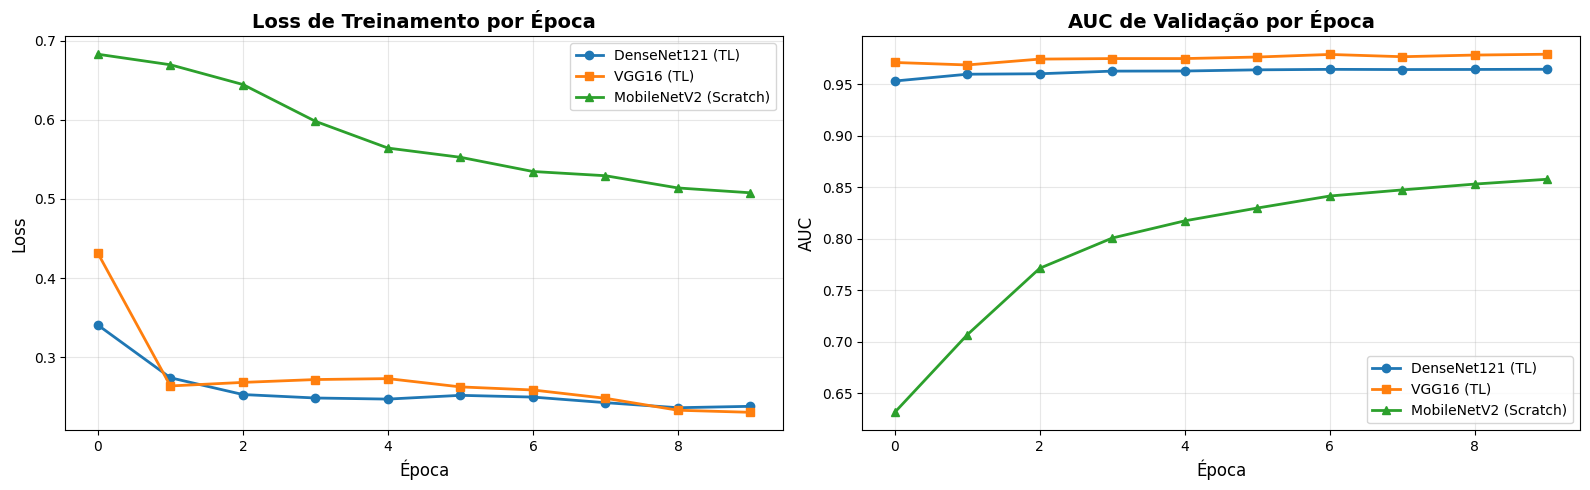

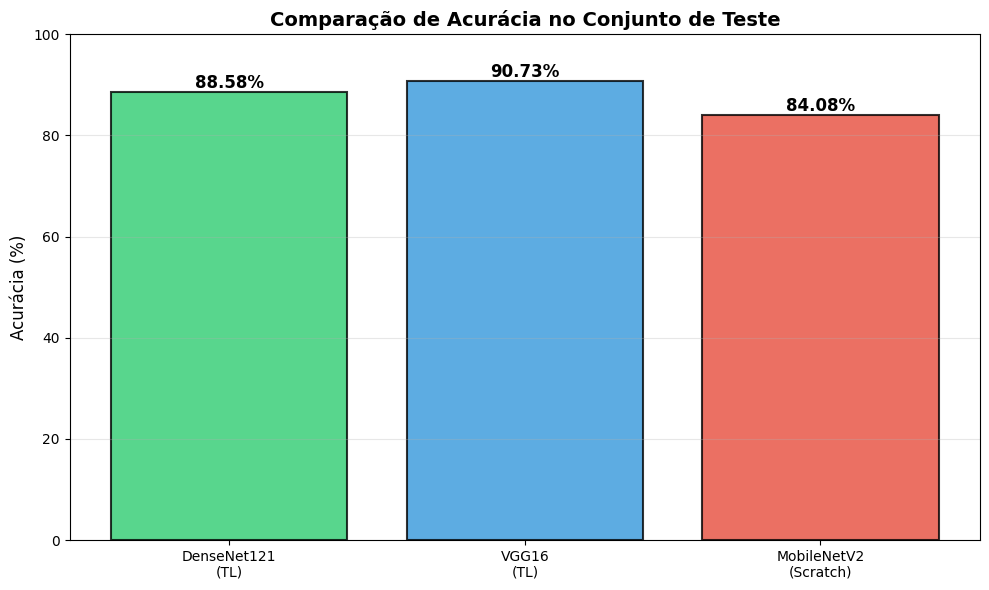


MATRIZES DE CONFUSÃO


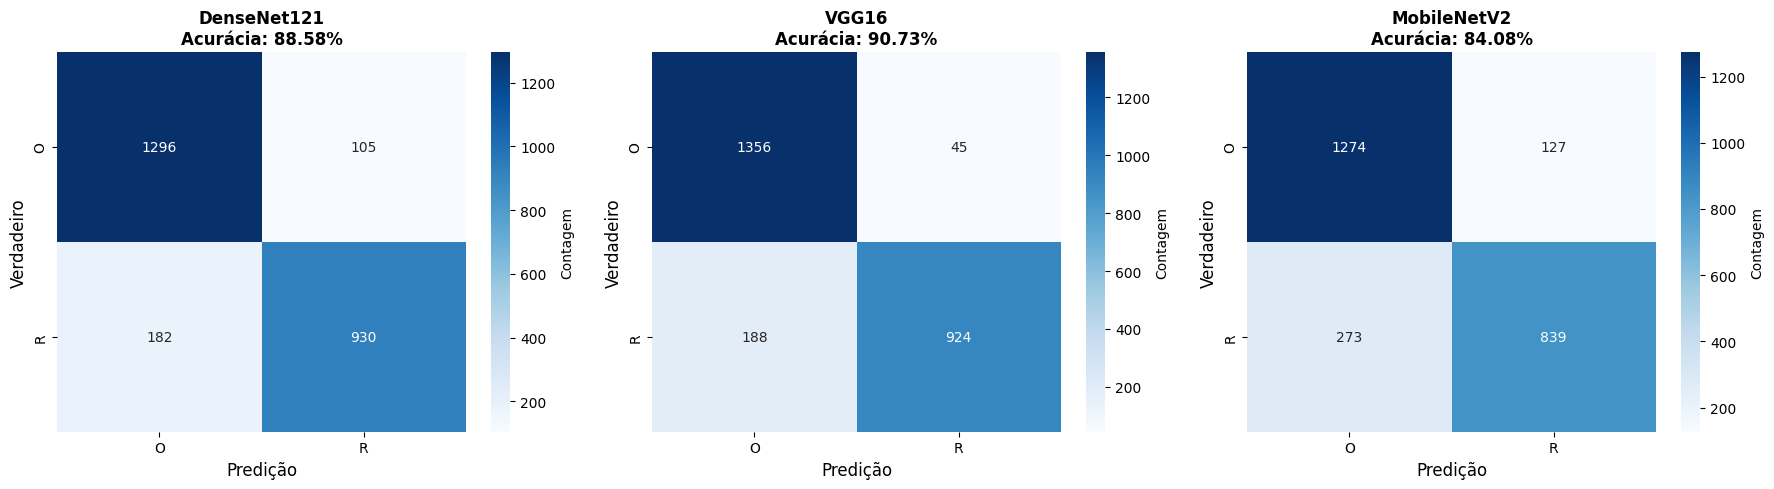


RELATÓRIOS DE CLASSIFICAÇÃO

----------------------------------DenseNet121-----------------------------------
              precision    recall  f1-score   support

           O     0.8769    0.9251    0.9003      1401
           R     0.8986    0.8363    0.8663      1112

    accuracy                         0.8858      2513
   macro avg     0.8877    0.8807    0.8833      2513
weighted avg     0.8865    0.8858    0.8853      2513


-------------------------------------VGG16--------------------------------------
              precision    recall  f1-score   support

           O     0.8782    0.9679    0.9209      1401
           R     0.9536    0.8309    0.8880      1112

    accuracy                         0.9073      2513
   macro avg     0.9159    0.8994    0.9045      2513
weighted avg     0.9116    0.9073    0.9063      2513


----------------------------------MobileNetV2-----------------------------------
              precision    recall  f1-score   support

           O    

In [ ]:
# ================================================================================
# 5. DATASET CUSTOMIZADO E TRANSFORMAÇÕES
# ================================================================================

print("\n" + "="*80)
print("CONFIGURAÇÃO DO DATASET E TRANSFORMAÇÕES")
print("="*80)

class WasteDataset(TorchDataset):
    """
    Dataset customizado que garante todas as imagens em RGB (3 canais)
    """
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert('RGB')  # Força RGB
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return {"img": img, "label": label}

# Valores de normalização ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Transformações para TREINO (com Data Augmentation)
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5), #ajustado de 0.5
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

# Transformações para VALIDAÇÃO e TESTE (sem augmentation)
val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Transformações configuradas:")
print(f"  - Treino: {len(train_transform.transforms)} operações (com augmentation)")
print(f"  - Val/Test: {len(val_test_transform.transforms)} operações (sem augmentation)")


# ================================================================================
# 6. DATALOADERS
# ================================================================================

print("\n" + "="*80)
print("CRIANDO DATALOADERS")
print("="*80)

BATCH_SIZE_TRAIN = 128  #alterado de 64
BATCH_SIZE_VAL_TEST = 128
NUM_WORKERS = 2

train_dataset = WasteDataset(trainX, trainY, transform=train_transform)
val_dataset = WasteDataset(valX, valY, transform=val_test_transform)
test_dataset = WasteDataset(testX, testY, transform=val_test_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE_TRAIN,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE_VAL_TEST,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE_VAL_TEST,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"Train Loader: {len(train_loader)} batches de {BATCH_SIZE_TRAIN}")
print(f"Val Loader:   {len(val_loader)} batches de {BATCH_SIZE_VAL_TEST}")
print(f"Test Loader:  {len(test_loader)} batches de {BATCH_SIZE_VAL_TEST}")


# ================================================================================
# 7. FUNÇÕES DE CONFIGURAÇÃO DOS MODELOS
# ================================================================================

print("\n" + "="*80)
print("FUNÇÕES DE CONFIGURAÇÃO DOS MODELOS")
print("="*80)

def setup_transfer_learning_model(model_name, num_classes, device):
    """Configura modelo para Transfer Learning (Feature Extraction)"""
    model = None
    print(f"\n  → Configurando {model_name.upper()} com Transfer Learning...")

    if model_name == 'densenet121':
        model = models.densenet121(weights="IMAGENET1K_V1")
        for param in model.parameters():
            param.requires_grad = False
        in_features = model.classifier.in_features
        model.classifier = nn.Linear(in_features, num_classes)

    elif model_name == 'vgg16':
        model = models.vgg16(weights="IMAGENET1K_V1")
        for param in model.features.parameters():
            param.requires_grad = False
        in_features = model.classifier[6].in_features
        model.classifier[6] = nn.Linear(in_features, num_classes)

    model = model.to(device)
    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3
    )

    # Contar parâmetros
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"    Total de parâmetros: {total_params:,}")
    print(f"    Parâmetros treináveis: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")

    return model, optimizer


def setup_scratch_model(num_classes, device):
    """Configura MobileNetV2 para treinamento do zero"""
    print(f"\n  Configurando MOBILENETV2 do Zero (Scratch)...")

    model = models.mobilenet_v2(weights=None)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    model = model.to(device)

    optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=0.01) #aqui ajustamos o layer de lr=1e-4

    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"    Total de parâmetros: {total_params:,}")
    print(f"    Parâmetros treináveis: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")

    return model, optimizer

print("Funções de configuração definidas")


# ================================================================================
# 8. FUNÇÕES DE TREINAMENTO E AVALIAÇÃO
# ================================================================================

print("\n" + "="*80)
print("FUNÇÕES DE TREINAMENTO E AVALIAÇÃO")
print("="*80)

"""
CORREÇÃO DO CÁLCULO DE AUC PARA CLASSIFICAÇÃO BINÁRIA
Substituir a função run_training_loop no código original
"""

import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import roc_auc_score

def run_training_loop(model, optimizer, train_loader, val_loader, device, epochs=10):
    """
    Loop de treinamento com validação - CORRIGIDO PARA BINARY CLASSIFICATION
    """
    loss_function = nn.CrossEntropyLoss()
    epoch_loss_values = []
    metric_values = []

    for epoch in range(epochs):
        print(f"\n{'─'*80}")
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"{'─'*80}")

        # ═══════════════════════════════════════════════════════════════
        # TREINO
        # ═══════════════════════════════════════════════════════════════
        model.train()
        epoch_loss = 0
        step = 0

        for batch in train_loader:
            step += 1
            inputs = batch["img"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

            if step % 50 == 0:
                print(f"  Batch {step:3d}/{len(train_loader)} │ Loss: {loss.item():.4f}")

        epoch_loss /= step
        epoch_loss_values.append(epoch_loss)

        # ═══════════════════════════════════════════════════════════════
        # VALIDAÇÃO - CORRIGIDO PARA BINARY CLASSIFICATION
        # ═══════════════════════════════════════════════════════════════
        model.eval()
        y_true = []
        y_prob = []

        with torch.no_grad():
            for batch in val_loader:
                inputs = batch["img"].to(device)
                labels = batch["label"].to(device)
                outputs = model(inputs)
                probs = torch.softmax(outputs, dim=1)

                y_true.extend(labels.cpu().numpy())
                y_prob.extend(probs.cpu().numpy())

        # Converter para arrays numpy
        y_true = np.array(y_true)
        y_prob = np.array(y_prob)

        # Calcular AUC - CORRIGIDO
        try:
            # Para classificação binária, usar apenas a probabilidade da classe positiva
            if y_prob.shape[1] == 2:  # Binary classification
                # Usar apenas a probabilidade da classe 1 (positiva)
                auc = roc_auc_score(y_true, y_prob[:, 1])
            else:  # Multi-class
                auc = roc_auc_score(y_true, y_prob, multi_class="ovr")

            metric_values.append(auc)
            print(f"\n  Train Loss: {epoch_loss:.4f} │ Val AUC: {auc:.4f}")

        except ValueError as e:
            # Se ainda falhar, calcular AUC manualmente ou usar 0
            print(f"\n  Train Loss: {epoch_loss:.4f} │ Val AUC: ERRO - {str(e)}")

            # Tentar diagnóstico
            unique_labels = np.unique(y_true)
            print(f"  DEBUG: Classes únicas no val: {unique_labels}")
            print(f"  DEBUG: Shape y_prob: {y_prob.shape}")
            print(f"  DEBUG: Shape y_true: {y_true.shape}")

            metric_values.append(0)

    return epoch_loss_values, metric_values




def evaluate_accuracy(model, test_loader, device):
    """Avalia acurácia no conjunto de teste"""
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in test_loader:
            inputs = batch["img"].to(device)
            labels = batch["label"].to(device)
            outputs = model(inputs)

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


def get_predictions(model, test_loader, device):
    """Obtém predições e labels verdadeiros"""
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in test_loader:
            inputs = batch["img"].to(device)
            labels = batch["label"].to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1)

            _, predicted = torch.max(outputs.data, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

print("Funções de treinamento definidas")


# ================================================================================
# 9. TREINAMENTO DOS MODELOS
# ================================================================================

print("\n" + "="*80)
print("INICIANDO TREINAMENTO DOS MODELOS")
print("="*80)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = len(class_names)
EPOCHS = 10

print(f"\nConfiguração:")
print(f"  Device: {device}")
print(f"  Número de classes: {num_classes}")
print(f"  Épocas: {EPOCHS}")

# Dicionário para armazenar resultados
results = {}

# ─────────────────────────────────────────────────────────────────────────────
# CENÁRIO A: TRANSFER LEARNING
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("CENÁRIO A: TRANSFER LEARNING")
print("="*80)

# 1. DenseNet121
print("\n" + "┌" + "─"*78 + "┐")
print("│" + " "*28 + "DENSENET121" + " "*38 + "│")
print("└" + "─"*78 + "┘")
model_dense, opt_dense = setup_transfer_learning_model('densenet121', num_classes, device)
loss_dense, auc_dense = run_training_loop(model_dense, opt_dense, train_loader, val_loader, device, EPOCHS)
acc_dense = evaluate_accuracy(model_dense, test_loader, device)
y_true_dense, y_pred_dense, y_prob_dense = get_predictions(model_dense, test_loader, device)
results['DenseNet121'] = {
    'loss': loss_dense,
    'auc': auc_dense,
    'accuracy': acc_dense,
    'y_true': y_true_dense,
    'y_pred': y_pred_dense,
    'y_prob': y_prob_dense
}
print(f"\n✓ Acurácia Final DenseNet121: {acc_dense:.2f}%")

# 2. VGG16
print("\n" + "┌" + "─"*78 + "┐")
print("│" + " "*32 + "VGG16" + " "*41 + "│")
print("└" + "─"*78 + "┘")
model_vgg, opt_vgg = setup_transfer_learning_model('vgg16', num_classes, device)
loss_vgg, auc_vgg = run_training_loop(model_vgg, opt_vgg, train_loader, val_loader, device, EPOCHS)
acc_vgg = evaluate_accuracy(model_vgg, test_loader, device)
y_true_vgg, y_pred_vgg, y_prob_vgg = get_predictions(model_vgg, test_loader, device)
results['VGG16'] = {
    'loss': loss_vgg,
    'auc': auc_vgg,
    'accuracy': acc_vgg,
    'y_true': y_true_vgg,
    'y_pred': y_pred_vgg,
    'y_prob': y_prob_vgg
}
print(f"\n✓ Acurácia Final VGG16: {acc_vgg:.2f}%")

# ─────────────────────────────────────────────────────────────────────────────
# CENÁRIO B: TREINAMENTO DO ZERO SEM TRANSFER LEARNING
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*80)
print("CENÁRIO B: TREINAMENTO DO ZERO (SCRATCH)")
print("="*80)

# 3. MobileNetV2
print("\n" + "┌" + "─"*78 + "┐")
print("│" + " "*29 + "MOBILENETV2" + " "*38 + "│")
print("└" + "─"*78 + "┘")
model_mobile, opt_mobile = setup_scratch_model(num_classes, device)
loss_mobile, auc_mobile = run_training_loop(model_mobile, opt_mobile, train_loader, val_loader, device, EPOCHS)
acc_mobile = evaluate_accuracy(model_mobile, test_loader, device)
y_true_mobile, y_pred_mobile, y_prob_mobile = get_predictions(model_mobile, test_loader, device)
results['MobileNetV2'] = {
    'loss': loss_mobile,
    'auc': auc_mobile,
    'accuracy': acc_mobile,
    'y_true': y_true_mobile,
    'y_pred': y_pred_mobile,
    'y_prob': y_prob_mobile
}
print(f"\n✓ Acurácia Final MobileNetV2: {acc_mobile:.2f}%")


# ================================================================================
# 10. VISUALIZAÇÃO DOS RESULTADOS
# ================================================================================

print("\n" + "="*80)
print("VISUALIZAÇÃO DOS RESULTADOS")
print("="*80)

# Gráfico de Loss e AUC
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss
axes[0].plot(loss_dense, label='DenseNet121 (TL)', marker='o', linewidth=2)
axes[0].plot(loss_vgg, label='VGG16 (TL)', marker='s', linewidth=2)
axes[0].plot(loss_mobile, label='MobileNetV2 (Scratch)', marker='^', linewidth=2)
axes[0].set_xlabel('Época', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Loss de Treinamento por Época', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# AUC
axes[1].plot(auc_dense, label='DenseNet121 (TL)', marker='o', linewidth=2)
axes[1].plot(auc_vgg, label='VGG16 (TL)', marker='s', linewidth=2)
axes[1].plot(auc_mobile, label='MobileNetV2 (Scratch)', marker='^', linewidth=2)
axes[1].set_xlabel('Época', fontsize=12)
axes[1].set_ylabel('AUC', fontsize=12)
axes[1].set_title('AUC de Validação por Época', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Gráfico de barras comparativo
fig, ax = plt.subplots(figsize=(10, 6))
models = ['DenseNet121\n(TL)', 'VGG16\n(TL)', 'MobileNetV2\n(Scratch)']
accuracies = [acc_dense, acc_vgg, acc_mobile]
colors = ['#2ecc71', '#3498db', '#e74c3c']

bars = ax.bar(models, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Acurácia (%)', fontsize=12)
ax.set_title('Comparação de Acurácia no Conjunto de Teste', fontsize=14, fontweight='bold')
ax.set_ylim([0, 100])
ax.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


# ================================================================================
# 11. MATRIZES DE CONFUSÃO
# ================================================================================

print("\n" + "="*80)
print("MATRIZES DE CONFUSÃO")
print("="*80)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, ax) in enumerate(zip(['DenseNet121', 'VGG16', 'MobileNetV2'], axes)):
    y_true = results[model_name]['y_true']
    y_pred = results[model_name]['y_pred']

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, cbar_kws={'label': 'Contagem'})

    ax.set_xlabel('Predição', fontsize=12)
    ax.set_ylabel('Verdadeiro', fontsize=12)
    ax.set_title(f'{model_name}\nAcurácia: {results[model_name]["accuracy"]:.2f}%',
                 fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


# ================================================================================
# 12. RELATÓRIOS DE CLASSIFICAÇÃO
# ================================================================================

print("\n" + "="*80)
print("RELATÓRIOS DE CLASSIFICAÇÃO")
print("="*80)

for model_name in ['DenseNet121', 'VGG16', 'MobileNetV2']:
    print(f"\n{model_name:-^80}")
    y_true = results[model_name]['y_true']
    y_pred = results[model_name]['y_pred']

    report = classification_report(
        y_true, y_pred,
        target_names=class_names,
        digits=4
    )
    print(report)


# ================================================================================
# 13. RESUMO FINAL
# ================================================================================

print("\n" + "="*80)
print("RESUMO FINAL DOS RESULTADOS")
print("="*80)

print(f"\n{'Modelo':<20} {'Acurácia':<12} {'AUC Final':<12} {'Abordagem'}")
print("─" * 80)
print(f"{'DenseNet121':<20} {acc_dense:>6.2f}%     {auc_dense[-1]:>6.4f}      Transfer Learning")
print(f"{'VGG16':<20} {acc_vgg:>6.2f}%     {auc_vgg[-1]:>6.4f}      Transfer Learning")
print(f"{'MobileNetV2':<20} {acc_mobile:>6.2f}%     {auc_mobile[-1]:>6.4f}      Treinamento do Zero")

best_model = max([
    ('DenseNet121', acc_dense),
    ('VGG16', acc_vgg),
    ('MobileNetV2', acc_mobile)
], key=lambda x: x[1])

print("\n" + "="*80)
print(f"MELHOR MODELO: {best_model[0]} com {best_model[1]:.2f}% de acurácia")
print("="*80)

print("\n Análise completa finalizada!")


## Discussão dos Resultados das Métricas e Estatísticas
* Analise crıtica dos resultados (discussao dos graficos e metricas)

##Conclusão
* (resumindo o projeto e refletindo sobre os aprendizados adquiridos ao longo do processo)

##Referencias

* MONAI Pytorch Framework: (https://github.com/Project-MONAI/MONAI?tab=readme-ov-file)
